In [1]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
import h5py
from scipy.linalg import expm
from numpy.linalg import pinv, eig, norm
from scipy.optimize import minimize_scalar
from scipy.interpolate import interp1d
from scipy.special import genlaguerre, factorial
import os
from tqdm import tqdm

%matplotlib widget

# Parameters

In [2]:
# file_output_nb = ['00' + str(i) for i in range(763, 863)]
# split = len(file_output_nb) // 4


file_output_nb_0 = ['00' + str(i) for i in range(930, 945)]
file_output_nb_2 = ['00' + str(i) for i in range(945, 960)]
file_output_nb_0p2 = ['00' + str(i) for i in range(900, 915)]
file_output_nb_0p2i = ['00' + str(i) for i in range(915, 930)]


file_input_nb= ['00896', '00897', '00898', '00899']


# eta_vec = np.linspace(0.1, 0.9, split)
filename =[[], [], [], []]
filename_input = []
state_input = ['0', '2', '0+2', '0+2i']
folder_path = '/Users/sebastien/Library/CloudStorage/GoogleDrive-sebleger@stanford.edu/Shared drives/SLab/Multimode/experiment/250505_craqm/data/'
N=10

# for i in range(len(file_output_nb)):
    # idx = i // split
    # print(f'Processing files: {file_output_nb[i]}')
    # filename[idx].append(os.path.join(folder_path, f'{file_output_nb[i]}_WignerTomography1ModeExperiment.h5'))


for i in range(len(file_output_nb_0)):
    print(f'Processing files: {file_output_nb_0[i]}')
    filename[0].append(os.path.join(folder_path, f'{file_output_nb_0[i]}_WignerTomography1ModeExperiment.h5'))
    print(f'Processing files: {file_output_nb_2[i]}')
    filename[1].append(os.path.join(folder_path, f'{file_output_nb_2[i]}_WignerTomography1ModeExperiment.h5'))
    print(f'Processing files: {file_output_nb_0p2[i]}')
    filename[2].append(os.path.join(folder_path, f'{file_output_nb_0p2[i]}_WignerTomography1ModeExperiment.h5'))
    print(f'Processing files: {file_output_nb_0p2i[i]}')
    filename[3].append(os.path.join(folder_path, f'{file_output_nb_0p2i[i]}_WignerTomography1ModeExperiment.h5'))

for i in range(len(file_input_nb)):
    print(f'Processing files: {file_input_nb[i]}')
    filename_input.append(os.path.join(folder_path, f'{file_input_nb[i]}_WignerTomography1ModeExperiment.h5'))

Processing files: 00930
Processing files: 00945
Processing files: 00900
Processing files: 00915
Processing files: 00931
Processing files: 00946
Processing files: 00901
Processing files: 00916
Processing files: 00932
Processing files: 00947
Processing files: 00902
Processing files: 00917
Processing files: 00933
Processing files: 00948
Processing files: 00903
Processing files: 00918
Processing files: 00934
Processing files: 00949
Processing files: 00904
Processing files: 00919
Processing files: 00935
Processing files: 00950
Processing files: 00905
Processing files: 00920
Processing files: 00936
Processing files: 00951
Processing files: 00906
Processing files: 00921
Processing files: 00937
Processing files: 00952
Processing files: 00907
Processing files: 00922
Processing files: 00938
Processing files: 00953
Processing files: 00908
Processing files: 00923
Processing files: 00939
Processing files: 00954
Processing files: 00909
Processing files: 00924
Processing files: 00940
Processing files

# Functions

# file import

In [3]:
# open the h5 file and return the keys

def get_keys(filename):

    with h5py.File(filename, 'r') as f:
        keys = list(f.keys())
    return keys


# open the h5 file store the data in a dictionary and close the file
def open_h5_file(filename):
    with h5py.File(filename, 'r') as f:
        data = {key: np.array(f[key]) for key in f.keys()}
    return data


## Wigner tomography

In [4]:
I = np.diag(np.ones(N), 0)
Par = np.real(np.diag(np.exp(1j * np.pi * (np.arange(0, N))), 0))

def D(beta, m):
    """
    Returns the displacement operator for a given beta using numpy.
    """
    # Create the raising and lowering operators
    M_p = np.diag(np.sqrt(np.arange(1, m)), 1)  # Raising operator
    M_m = np.diag(np.sqrt(np.arange(1, m)), -1)  # Lowering operator
    return expm(beta * M_m - np.conj(beta) * M_p)[:m, :m]

def wigner_analysis_results(allocated_counts, initial_state, alphas, N, rotate=False):
    m = N
    alpha_list = alphas
    allocated_readout = 2 / np.pi * allocated_counts  # normalization
    initial_state = initial_state.unit()

    # check initial_state dims to see if ket or dm 
    dims = initial_state.dims 
    if dims[1]==[1]:
        rho_ideal = qt.ket2dm(initial_state).unit()
    elif dims[0]==dims[1]:
        rho_ideal = initial_state
    else:
        raise ValueError("Invalid initial state")

    alphas2 = np.arange(-np.sqrt(m) / np.sqrt(1) + 0.1, np.sqrt(m) / np.sqrt(1), 0.05)
    rho = rho_pinv_positive_sd(allocated_readout, m, alphas=alpha_list)  # Only m needed
    P_ns = [np.array([rho[i][i] for i in range(m)])]

    fid = qt.fidelity(qt.Qobj(rho), rho_ideal)**2

    if rotate:
        theta = np.linspace(0, 2 * np.pi, 100)
        fid_vec = np.zeros(len(theta))
        for i, t in enumerate(theta):
            N = np.diag(np.arange(m))
            R = expm(-1j * t * N)
            rho_rotated = R @ rho @ R.conj().T
            fid_rotated = qt.fidelity(qt.Qobj(rho_rotated), rho_ideal)**2
            fid_vec[i] = fid_rotated

        fid = np.max(fid_vec)
        R = expm(-1j * theta[np.argmax(fid_vec)] * N)
        rho = R @ rho @ R.conj().T
        theta_opt = theta[np.argmax(fid_vec)]

    else: 
        theta_opt = 0


    return {
        'alpha_list': alpha_list,
        'allocated_readout': allocated_readout,
        'rho': rho,
        'rho_ideal': rho_ideal,
        'P_ns': P_ns,
        'alphas2': alphas2,
        'fidelity': fid,
        'theta_opt': theta_opt
    }

def rho_pinv_positive_sd(w_vec, m, alphas):
    rho = rho_pinv_trace_1(w_vec, m, alphas)
    l, v = eig(rho)
    ls_index = sorted(range(len(l)), key=lambda k: l[k], reverse=True)
    ls = sorted(l, reverse=True)
    vs = np.array([v.T.conj()[i] for i in ls_index])
    lps = positive_semidefinite_eigs(ls)
    rho_new = np.dot((np.array(vs).T.conj()), np.dot(np.diag(lps, 0), np.array(vs)))
    return rho_new

def positive_semidefinite_eigs(eigs):
    d = len(eigs)
    vout = np.copy(eigs)
    a = 0
    for i in sorted(range(d), reverse=True):
        if eigs[i] + a / (i + 1) < 0:
            a += eigs[i]
            vout[i] = 0
        else:
            break
    if i != d - 1:
        vout[:i + 1] = eigs[:i + 1] + a / (i + 1)
    return vout

def rho_pinv_trace_1(w_vec, m, alphas):
    x = w_vec
    i_vec = I.flatten()
    A = np.zeros([m ** 2 + 1, m ** 2 + 1], dtype=np.complex128)
    wig_tens, _, _ = curlyM(alphas, m)  
    # A[:m ** 2, :m ** 2] = np.dot(np.conjugate(np.transpose(curlyM(alphas, m))), curlyM(alphas, m))
    A[:m ** 2, :m ** 2] = np.dot(np.conjugate(np.transpose(wig_tens)), wig_tens)
    A[m ** 2, m ** 2], A[m ** 2][:m ** 2], A.T[m ** 2][:m ** 2] = 0, i_vec, i_vec
    vec_b = np.ones([m ** 2 + 1], dtype=np.complex128)
    # vec_b[:m ** 2] = np.dot(np.conjugate(np.transpose(curlyM(alphas, m))), w_vec)
    vec_b[:m ** 2] = np.dot(np.conjugate(np.transpose(wig_tens)), w_vec)
    rho_vec = np.dot(pinv(A), vec_b)[:m ** 2]
    rho = rho_vec.reshape(m, m)
    return rho

def curlyM(alphas, m, analytic=True):
    if analytic:
        return wigner_mat_and_grad(alphas, m, reshape=True)
    else:
        M_mat = np.array([W_op(alpha, m, analytic=False) for alpha in alphas])
        return np.array([np.transpose(m).flatten() for m in M_mat])

def wigner_mat_and_grad(disps, FD, reshape=True):
    ND = len(disps)
    # seb: for some reason I need to apply a phase shift to disps
    disps = np.abs(disps) * np.exp(1j * (np.angle(disps) + np.pi))
    wig_tens = np.zeros((ND, FD, FD), dtype=np.complex128)
    grad_mat_r = np.zeros((ND, FD, FD), dtype=np.complex128)
    grad_mat_i = np.zeros((ND, FD, FD), dtype=np.complex128)
    B = 4 * abs(disps) ** 2
    pf = (2 / np.pi) * np.exp(-B / 2.0)

    for m in range(FD):
        x = pf * np.real((-1) ** m * genlaguerre(m, 0)(B))
        term_r = -4 * disps.real * x
        term_i = -4 * disps.imag * x
        if m > 0:
            y = 8 * pf * (-1) ** (m - 1) * genlaguerre(m - 1, 1)(B)
            term_r += disps.real * y
            term_i += disps.imag * y
        wig_tens[:, m, m] = x
        grad_mat_r[:, m, m] = term_r
        grad_mat_i[:, m, m] = term_i
        for n in range(m + 1, FD):
            pf_nm = np.sqrt(factorial(m) / float(factorial(n)))
            x = pf * pf_nm * (-1) ** m * 2 * (2 * disps) ** (n - m - 1) * genlaguerre(m, n - m)(B)
            term_r = ((n - m) - 4 * disps.real * disps) * x
            term_i = (1j * (n - m) - 4 * disps.imag * disps) * x
            if m > 0:
                y = 8 * pf * pf_nm * (-1) ** (m - 1) * (2 * disps) ** (n - m) * genlaguerre(m - 1, n - m + 1)(B)
                term_r += disps.real * y
                term_i += disps.imag * y
            wig_tens[:, m, n] = disps * x
            wig_tens[:, n, m] = (disps * x).conj()
            grad_mat_r[:, m, n] = term_r
            grad_mat_r[:, n, m] = term_r.conjugate()
            grad_mat_i[:, m, n] = term_i
            grad_mat_i[:, n, m] = term_i.conjugate()

    if reshape:
        return (wig_tens.reshape((ND, FD ** 2)), grad_mat_r.reshape((ND, FD ** 2)), grad_mat_i.reshape((ND, FD ** 2)))
    else:
        return (wig_tens, grad_mat_r, grad_mat_i)

def W_op(alpha, m, analytic=True):
    if analytic:
        w = np.zeros((m, m), dtype=np.complex128)
        B = 4 * abs(alpha) ** 2
        pf = (2 / np.pi) * np.exp(-B / 2.0)
        for mm in range(m):
            x = pf * np.real((-1) ** mm * genlaguerre(mm, 0)(B))
            w[mm, mm] = x
            for n in range(mm + 1, m):
                pf_nm = np.sqrt(factorial(mm) / float(factorial(n)))
                x = pf * pf_nm * (-1) ** mm * 2 * (2 * alpha) ** (n - mm - 1) * genlaguerre(mm, n - mm)(B)
                if mm > 0:
                    y = 8 * pf * pf_nm * (-1) ** (mm - 1) * (2 * alpha) ** (n - mm) * genlaguerre(mm - 1, n - mm + 1)(B)
                w[mm, n] = alpha * x
                w[n, mm] = (alpha * x).conj()
    else:
        w = 2 / np.pi * np.dot(D(-alpha, m), np.dot(Par, D(alpha, m)))
    
    return w

## Transduction

In [5]:
def channel_output(eta, cutoff=N):
    fock_0 = qt.basis(cutoff, 0)
    fock_1 = qt.basis(cutoff, 1)
    fock_2 = qt.basis(cutoff, 2)
    fock_3 = qt.basis(cutoff, 3)

    N_00 = eta * qt.ket2dm(fock_0) + (1-eta) * qt.ket2dm(fock_1)
    N_02 = eta*(3*eta - 2) * fock_0*fock_2.dag() + np.sqrt(3)*eta*(1-eta)*fock_1*fock_3.dag()
    N_20 = eta*(3*eta - 2) * fock_2*fock_0.dag() + np.sqrt(3)*eta*(1-eta)*fock_3*fock_1.dag()
    N_22 = eta*(3*eta - 2)**2 *qt.ket2dm(fock_2) + 3*eta*(1-eta)**2*qt.ket2dm(fock_0) + \
            3*eta**2*(1-eta)*qt.ket2dm(fock_3) + (1-eta)*(1-3*eta)**2*qt.ket2dm(fock_1)
    
    N_pp = 1/2 * (N_00 + N_22 + N_02 + N_20)
    N_ipip = 1/2 * (N_00 + N_22 - 1j*N_02 + 1j*N_20)

    return [N_00, N_02, N_20, N_22, N_pp, N_ipip]


def decoding(rho_out, eta, cutoff=N):
    fock_0 = qt.basis(cutoff, 0)
    fock_1 = qt.basis(cutoff, 1)
    fock_2 = qt.basis(cutoff, 2)
    fock_3 = qt.basis(cutoff, 3)

    if eta < 2/3:
        K0 = fock_0*fock_0.dag() - fock_1*fock_2.dag()
    else:
        K0 = fock_0*fock_0.dag() + fock_1*fock_2.dag()
    K1 = fock_0*fock_1.dag() + fock_1*fock_3.dag()
    return K0*rho_out*K0.dag() + K1*rho_out*K1.dag()

def entanglement_fidelity(rho_00, rho_20, rho_02, rho_22, eta, cutoff=N):
    rho_00_dec = decoding(rho_00, eta, cutoff=cutoff)
    rho_22_dec = decoding(rho_22, eta, cutoff=cutoff)
    rho_20_dec = decoding(rho_20, eta, cutoff=cutoff)
    rho_02_dec = decoding(rho_02, eta, cutoff=cutoff)

    b0 = qt.basis(cutoff, 0)
    b1 = qt.basis(cutoff, 1)

    F = 1/4 * (b0.dag()*rho_00_dec*b0 + b1.dag()*rho_22_dec*b1 + b0.dag()*rho_02_dec*b1 + b1.dag()*rho_20_dec*b0)
    return np.real(F)

def coherent_information(rho_00, rho_20, rho_02, rho_22, eta, cutoff=N, decoding=True):

    if decoding: 
        rho_00_dec = decoding(rho_00, eta, cutoff=cutoff)
        rho_22_dec = decoding(rho_22, eta, cutoff=cutoff)
        rho_20_dec = decoding(rho_20, eta, cutoff=cutoff)
        rho_02_dec = decoding(rho_02, eta, cutoff=cutoff)

        b0 = qt.basis(cutoff, 0)
        b1 = qt.basis(cutoff, 1)

        rho_1 = 1/2 * (rho_00_dec + rho_22_dec)
        rho_2 = 1/2 *(qt.tensor(b0*b0.dag(), rho_00_dec) + qt.tensor(b1*b1.dag(), rho_22_dec) + qt.tensor(b0*b1.dag(), rho_02_dec) + qt.tensor(b1*b0.dag(), rho_20_dec))

    else: 

        b0 = qt.basis(cutoff, 0)
        b1 = qt.basis(cutoff, 2)


        rho_1 = 1/2 * (rho_00 + rho_22)
        rho_2 = 1/2 *(qt.tensor(b0*b0.dag(), rho_00) + qt.tensor(b1*b1.dag(), rho_22) + qt.tensor(b0*b1.dag(), rho_02) + qt.tensor(b1*b0.dag(), rho_20))




    S1 = qt.entropy_vn(rho_1)
    S2 = qt.entropy_vn(rho_2)

    return S1 - S2

def input_str_to_output(input_str, eta, cutoff=N):
    # Parse the input string
    N_00, N_02, N_20, N_22, N_pp, N_ipip = channel_output(eta, cutoff=cutoff)
    if input_str =='0':
        return N_00
    elif input_str =='2':
        return N_22
    elif input_str =='0+2':
        return N_pp
    elif input_str =='0+2i':
        return N_ipip
    else:
        raise ValueError(f"Unknown input state: {input_str}")   
    
def input_str_to_state(input_str, cutoff=N):
    fock_0 = qt.basis(cutoff, 0)
    fock_2 = qt.basis(cutoff, 2)
    if input_str =='0':
        return fock_0
    elif input_str =='2':
        return fock_2
    elif input_str =='0+2':
        return (fock_0 + fock_2).unit()
    elif input_str =='0+2i':
        return (fock_0 + 1j*fock_2).unit()
    else:
        raise ValueError(f"Unknown input state: {input_str}")

In [6]:
data_input = {}

for i in range(len(filename_input)):
    data_input[state_input[i]] = open_h5_file(filename_input[i])
    _alpha = data_input[state_input[i]]['alpha']
    _parity = data_input[state_input[i]]['parity']
    rho_ideal = input_str_to_state(state_input[i], cutoff=N)
    res = wigner_analysis_results(_parity, rho_ideal, _alpha, N, rotate=True)
    data_input[state_input[i]]['rho'] = res['rho']
    data_input[state_input[i]]['fidelity'] = res['fidelity']
    data_input[state_input[i]]['theta_opt'] = res['theta_opt']
    data_input[state_input[i]]['rho_ideal'] = res['rho_ideal']
    

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/Users/sebastien/Library/CloudStorage/GoogleDrive-sebleger@stanford.edu/Shared drives/SLab/Multimode/experiment/250505_craqm/data/00896_WignerTomography1ModeExperiment.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [ ]:
data_output={}
for state in state_input:
    data_output[state] = {}

for i in tqdm(range(len(state_input))):
    rho_list = []
    rho_ideal_list = []
    rho_output_ideal_list = []
    fid_list = []
    theta_list = []
    eta_vec = np.zeros(len(filename[i]))
    for f in tqdm(range(len(filename[i]))):
        # data['filename'] = filename[i]
        _data_temp = open_h5_file(filename[i][f])
        if f == 0:
            _alpha = _data_temp['alpha']
            data_output[state_input[i]]['alpha'] = _alpha
        eta_vec[f] = _data_temp['eta']

        rho_ideal = input_str_to_output(state_input[i], eta_vec[f], cutoff=N)
        rho_ideal_list.append(rho_ideal)
        _parity = _data_temp['parity']

        data_output[state_input[i]]['parity'] = _parity

        result = wigner_analysis_results(
                allocated_counts=data_output[state_input[i]]['parity'],
                initial_state=rho_ideal,
                alphas=data_output[state_input[i]]['alpha'],
                N=N,
                rotate=True
            )
        

        N_00, N_02, N_20, N_22, N_pp, N_ipip = channel_output(eta_vec[f], cutoff=N)
        rho_input = data_input[state_input[i]]['rho']
        rho_output_ideal = N_00*rho_input[0, 0] + N_02*rho_input[0, 2] + N_20*rho_input[2, 0] + N_22*rho_input[2, 2]
        rho_output_ideal_list.append(rho_output_ideal)
        rho_list.append(result['rho'])
        fid_list.append(result['fidelity'])
        theta_list.append(result['theta_opt']%np.pi)

    data_output[state_input[i]]['rho'] = rho_list
    data_output[state_input[i]]['rho_ideal'] = rho_ideal_list
    data_output[state_input[i]]['fidelity'] = fid_list
    data_output[state_input[i]]['theta_opt'] = theta_list
    data_output[state_input[i]]['eta'] = eta_vec
    data_output[state_input[i]]['rho_output_ideal'] = rho_output_ideal_list


100%|██████████| 4/4 [00:03<00:00,  1.02it/s]


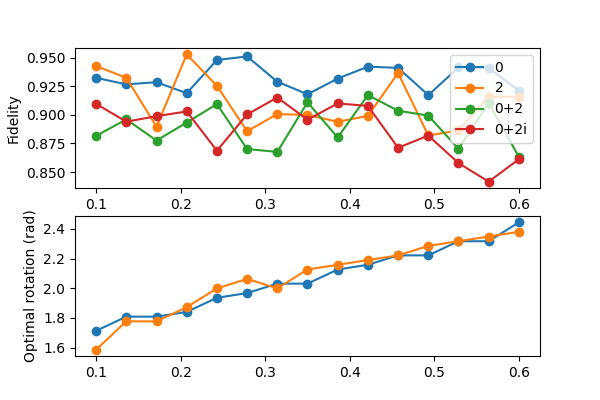

In [227]:
fig, ax = plt.subplots(2, 1, figsize=(6, 4))    

eta_vec = data_output[state_input[0]]['eta']


[ax[0].plot(eta_vec, data_output[state_input[i]]['fidelity'], marker='o', label=state_input[i]) for i in range(len(state_input))]
[ax[1].plot(eta_vec, data_output[state_input[i]]['theta_opt'], marker='o', label=state_input[i]) for i in [2,3]]
ax[0].set_xlabel('$\eta$')
ax[0].set_ylabel('Fidelity')
ax[1].set_ylabel('Optimal rotation (rad)')
ax[0].legend() 

In [228]:
F = np.zeros(len(eta_vec))
Ic = np.zeros(len(eta_vec))
eta_th = np.linspace(eta_vec[0], eta_vec[-1], 300)
F_ideal = np.zeros(len(eta_th))
Ic_ideal = np.zeros(len(eta_th))

F_corrected = np.zeros(len(eta_vec))
Ic_corrected = np.zeros(len(eta_vec))

for i in tqdm(range(len(eta_vec))):

    rho_00 = qt.Qobj(data_output[state_input[0]]['rho'][i], dims=[[N], [N]])
    rho_22 = qt.Qobj(data_output[state_input[1]]['rho'][i], dims=[[N], [N]])
    rho_pp = qt.Qobj(data_output[state_input[2]]['rho'][i], dims=[[N], [N]])
    rho_ipip = qt.Qobj(data_output[state_input[3]]['rho'][i], dims=[[N], [N]])
    rho_20 = rho_pp - 1j*rho_ipip - (1 - 1j) / 2*(rho_00 + rho_22)
    rho_02 = rho_pp + 1j*rho_ipip - (1 + 1j) / 2*(rho_00 + rho_22)
    F[i] = entanglement_fidelity(rho_00, rho_20, rho_02, rho_22, eta_vec[i], cutoff=N)
    Ic[i] = coherent_information(rho_00, rho_20, rho_02, rho_22, eta_vec[i], cutoff=N, decoding=False)


for i in range(len(eta_th)):

    rho_00_ideal = input_str_to_output(state_input[0], eta_th[i], cutoff=N)
    rho_22_ideal = input_str_to_output(state_input[1], eta_th[i], cutoff=N)
    rho_pp_ideal = input_str_to_output(state_input[2], eta_th[i], cutoff=N)
    rho_ipip_ideal = input_str_to_output(state_input[3], eta_th[i], cutoff=N)
    rho_20_ideal = rho_pp_ideal - 1j*rho_ipip_ideal - (1 - 1j) / 2*(rho_00_ideal + rho_22_ideal)
    rho_02_ideal = rho_pp_ideal + 1j*rho_ipip_ideal - (1 + 1j) / 2*(rho_00_ideal + rho_22_ideal)

    F_ideal[i] = entanglement_fidelity(rho_00_ideal, rho_20_ideal, rho_02_ideal, rho_22_ideal, eta_th[i], cutoff=N)
    Ic_ideal[i] = coherent_information(rho_00_ideal, rho_20_ideal, rho_02_ideal, rho_22_ideal, eta_th[i], cutoff=N, decoding=False)
 


100%|██████████| 15/15 [00:00<00:00, 190.38it/s]


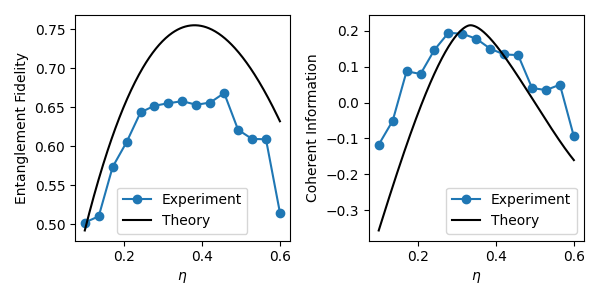

In [229]:
fig, ax = plt.subplots(1, 2, figsize=(6, 3), sharex=True)
ax[0].plot(eta_vec, F, marker='o', label='Experiment')
ax[0].plot(eta_th, F_ideal, label='Theory', color='black')
ax[0].set_xlabel('$\eta$')
ax[0].set_ylabel('Entanglement Fidelity')
ax[0].legend()
ax[1].plot(eta_vec, Ic, marker='o', label='Experiment')
ax[1].plot(eta_th, Ic_ideal, label='Theory', color='black')
ax[1].set_xlabel('$\eta$')
ax[1].set_ylabel('Coherent Information')
ax[1].legend()
fig.tight_layout()
fig.savefig('comp_theory.png', dpi=300)



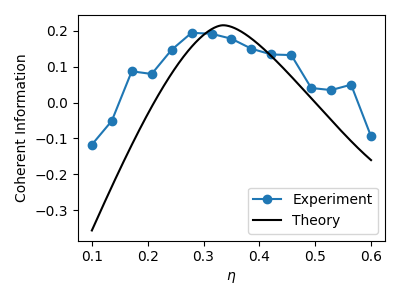

In [230]:
fig, ax = plt.subplots(1, 1, figsize=(4, 3))
ax.plot(eta_vec, Ic, marker='o', label='Experiment')
ax.plot(eta_th, Ic_ideal, label='Theory', color='black')
ax.set_xlabel('$\eta$')
ax.set_ylabel('Coherent Information')
ax.legend()
fig.tight_layout()
fig.savefig('coherent_information.png', dpi=300)